# 5. LightGBM
- Gradient boosting — builds trees sequentially, each correcting errors of the previous
- Faster and more memory-efficient than XGBoost — better suited for modest hardware
- Does not need scaling. Tree-based, same as RF
- Uses TreeExplainer for SHAP — fast and exact, same as RF
- Key difference from RF: boosting vs bagging — genuinely independent method

### IMPORT ORDER

In [1]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import datetime
import joblib

### Data Prep

In [15]:
# Load survey data
data = pd.read_csv('df_single_with_grps.csv')

# We drop some columns that are not useful or have too many levels
to_remove = ['age', 'age_grp', 'gender', 'educstat', 'comp_related_degree', 'city_ph', 'city_non_ph','region_ph', 'salary', 'country', 'industry', 'resp_id_rand', 'resp_id']
data = data[data['satisfaction'] != 999.0]

target = 'satisfaction'
X = data.drop(columns=[target] + to_remove)
y = data[target]

ordinal_maps = {
    'salary_broader': {
        '35k and less': 1,
        '35k+ to 75k':       2,
        '75k+ to 100k':      3,
        '100k and above':         4,
    },
    'how_long_in_salary': {
        'a. 3mos or less':    1,
        'b. >3 to 6mos':      2,
        'c. >6mos to 1yr':    3,
        'd. >1yr to 2yrs':    4,
        'e. >2 yrs to 5yrs':  5,
        'f. >5 yrs to 10yrs': 6,
        'g. >10yrs':          7,
    },
    'sizeteam': {
        '1 - Just me': 1,
        '2 to 3':      2,
        '4 to 5':      3,
        '6 to 10':     4,
        '11 to 30':    5,
        '30+':         6,
    },
}

for col, mapping in ordinal_maps.items():
    if col in X.columns:
        X[col] = X[col].map(mapping)

nominal_cols = [
    "have_comp_degree", "careerstg", "employertype", "typework", "sitework", "how_long_in_salary",
    "shift_schedule", "datarole", "side_gig", "ai_work", "ai_study"
]

# Nominal columns — one-hot encode, no implied order
nominal_cols = [c for c in nominal_cols if c in X.columns]
X = pd.get_dummies(X, columns=nominal_cols)

for column in X.select_dtypes(include=['object']).columns:
    X[column] = LabelEncoder().fit_transform(X[column])

print(X.dtypes)
print ("~"*75)
print("Nominal columns defined and one-hot encoded.  Ordinal columns transformed.")
print("Data loaded and prepared.  Date and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

sizeteam                                                                   float64
salary_broader                                                               int64
have_comp_degree_Have comp or data degree                                     bool
have_comp_degree_Not have                                                     bool
careerstg_Career shifter - currently working in a non-data-related role       bool
                                                                            ...   
ai_study_No, but I plan to soon.                                              bool
ai_study_None of the above                                                    bool
ai_study_Yes, I use AI tools DAILY for study.                                 bool
ai_study_Yes, I use AI tools MONTHLY or LESS frequently for study.            bool
ai_study_Yes, I use AI tools WEEKLY for study                                 bool
Length: 69, dtype: object
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

In [16]:
# 0.1 Drop NAs
X = X.dropna()
# Drop one-hot encoded columns with 'none of the above'
ohe_cols_to_drop = [col for col in X.columns if 'none of the above' in col.lower()]
X = X.drop(columns=ohe_cols_to_drop)
y = y[X.index]
print("NAs and None of the above one-hot-encoded columns dropped.  Date and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

NAs and None of the above one-hot-encoded columns dropped.  Date and Time:  2026/08/13 13:05:56


In [17]:
# 0.2 Check the range of satisfaction scores to ensure 999.0 was dropped
print(data['satisfaction'].describe())
print("Data checked.  Date and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

count    808.000000
mean       6.001238
std        2.491870
min        1.000000
25%        5.000000
50%        6.000000
75%        8.000000
max       10.000000
Name: satisfaction, dtype: float64
Data checked.  Date and Time:  2026/08/13 13:05:59


In [18]:
# 0.3 Save X as X.csv
X.to_csv("X.csv", index=False)
y.to_csv("y.csv", index=False)

### LightGBM

In [19]:
shap_comparison = pd.read_csv('shap_bin/shap_comparison.csv', index_col=0)
top20 = shap_comparison.head(20).index.tolist()
X_top20 = X[top20]

In [20]:
# Pre-clean column names

import re

# Clean column names for LightGBM compatibility
# Replaces special JSON characters with underscores
X_top20.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', col)
    for col in X_top20.columns
]

print("Cleaned column names:")
print(X_top20.columns.tolist())
print("Date and Time: ",
      datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

Cleaned column names:
['careerstg_Career_shifter___currently_working_in_a_non_data_related_role', 'salary_broader', 'sizeteam', 'ai_study_Yes__I_use_AI_tools_DAILY_for_study_', 'sitework_Mostly_work_from_home__fully_remote', 'ai_work_Yes__I_use_AI_tools_MONTHLY_or_LESS_frequently_for_work_', 'sitework_Mostly_onsite', 'how_long_in_salary_4_0', 'datarole_Admin___Support_Role', 'ai_work_Yes__I_use_AI_tools_DAILY_for_work_', 'how_long_in_salary_5_0', 'shift_schedule_Night_shift', 'ai_study_No__but_I_plan_to_soon_', 'employertype_Local_employer', 'how_long_in_salary_1_0', 'employertype_Foreign_employer', 'shift_schedule_Flexible', 'how_long_in_salary_2_0', 'datarole_Data_Analysis___Insights', 'datarole_Data_Processing___Entry']
Date and Time:  2026/08/13 13:06:29


In [30]:
# LightGBM imported earlier
# Best for gradient boosting on modest hardware
# Sequentially corrects errors — different mechanic from RF's parallel bagging
# No scaling needed. TreeExplainer supported for fast SHAP

lgbm_tool = lgb.LGBMRegressor(
    n_estimators=100,
    random_state=42,
    verbose=-1
)
lgbm_tool.fit(X_top20, y)

lgbm_impact = pd.DataFrame({
    'Driver': X_top20.columns,
    'Score':  lgbm_tool.feature_importances_
})
lgbm_impact = lgbm_impact.sort_values(by='Score', ascending=False)
lgbm_impact.to_csv('impact/lgbm_impact.csv', index=False)

# Save model
joblib.dump(lgbm_tool, 'models/model_lgbm.pkl')

# Load model
# lgbm_tool = joblib.load('models/model_lgbm.pkl')

print(lgbm_impact.sort_values(by='Score', ascending=False))
print("LightGBM done. Model saved. Date and Time: ",
      datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

                                               Driver  Score
2                                            sizeteam    388
1                                      salary_broader    239
13                        employertype_Local_employer    132
3       ai_study_Yes__I_use_AI_tools_DAILY_for_study_    123
4        sitework_Mostly_work_from_home__fully_remote    123
18                  datarole_Data_Analysis___Insights    121
6                              sitework_Mostly_onsite    105
9         ai_work_Yes__I_use_AI_tools_DAILY_for_work_     93
7                              how_long_in_salary_4_0     87
0   careerstg_Career_shifter___currently_working_i...     86
10                             how_long_in_salary_5_0     77
15                      employertype_Foreign_employer     72
5   ai_work_Yes__I_use_AI_tools_MONTHLY_or_LESS_fr...     48
11                         shift_schedule_Night_shift     47
12                   ai_study_No__but_I_plan_to_soon_     42
17                      

### SHAP for lgbm

In [23]:
import shap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
os.makedirs('assets', exist_ok=True)
os.makedirs('shap_bin', exist_ok=True)

print("Shap and matplotlib imported. Dirs assets and shap_bin created. \nDate and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

Shap and matplotlib imported. Dirs assets and shap_bin created. 
Date and Time:  2026/08/13 13:18:55


In [24]:
# Helper function to use aqua grey for shap plots and save in assets dir

def plot_shap(shap_values, title, filename_prefix):
    cmap = mcolors.LinearSegmentedColormap.from_list(
        'aqua_grey', ['#B0BEC5', '#2E86AB']
    )
    # Bar plot
    shap.plots.bar(shap_values, max_display=10, show=False)
    fig = plt.gcf()
    ax  = fig.axes[0]
    fig.patch.set_facecolor('#F5F5F5')   # outer background
    ax.set_facecolor('#F6F6F6')          # plot area background
    for patch in ax.patches:
        patch.set_facecolor("#021A42")   # navy blue bars
    for text in ax.texts:
        text.set_color('#37474F')
    plt.title(title)
    plt.savefig(f'assets/{filename_prefix}_bar.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()

    # Beeswarm plot
    shap.plots.beeswarm(shap_values, max_display=10, color=cmap, show=False)
    fig = plt.gcf()
    ax  = fig.axes[0]
    fig.patch.set_facecolor('#F5F5F5')   # outer background
    ax.set_facecolor("#F6F6F6")          # plot area background
    for text in ax.texts:
        text.set_color('#37474F')
    plt.title(title)
    plt.savefig(f'assets/{filename_prefix}_beeswarm.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()

print("Helper function for colors done.  Date and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

Helper function for colors done.  Date and Time:  2026/08/13 13:19:11


### SHAP explainer for LGBM

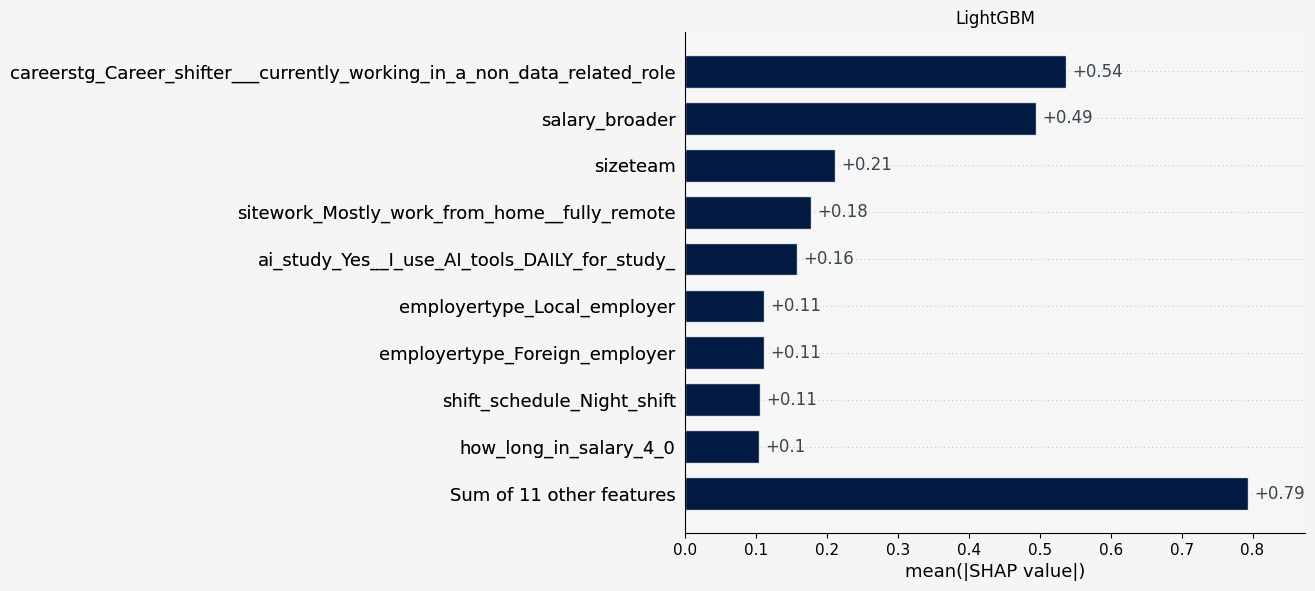

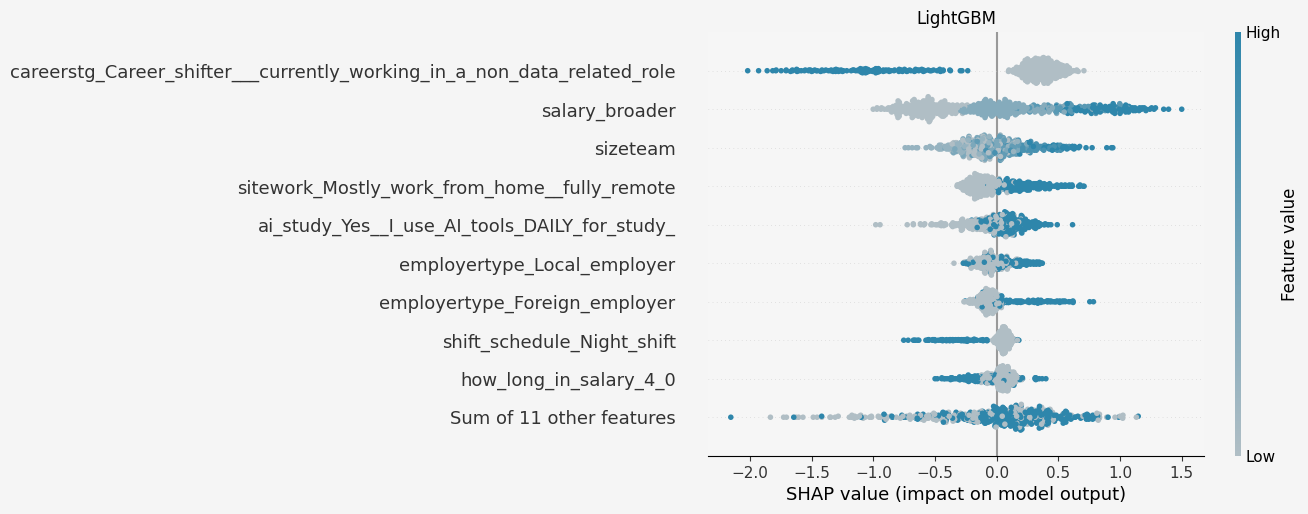

LightGBM SHAP done. Date and Time:  2026/08/13 13:36:17


In [29]:
# LightGBM SHAP using TreeExplainer — same as RF
# Fast and exact for tree-based models
# Remember we are now using X_top20 instead of X

explainer_lgbm   = shap.TreeExplainer(lgbm_tool)
shap_values_lgbm = explainer_lgbm(X_top20)

# Force clean numpy array — same pattern as LR and Lasso fixes
shap_values_lgbm_fixed = shap.Explanation(
    values        = np.array(shap_values_lgbm.values,       dtype=np.float64),
    base_values   = np.array(shap_values_lgbm.base_values,  dtype=np.float64),
    data          = np.array(shap_values_lgbm.data,         dtype=np.float64),
    feature_names = list(X_top20.columns)
)

plot_shap(shap_values_lgbm_fixed, "LightGBM", "shap_lgbm")

np.save('shap_bin/shap_lgbm.npy', shap_values_lgbm_fixed.values)
joblib.dump(shap_values_lgbm_fixed, 'shap_bin/shap_lgbm_explanation.pkl')

# Load
# shap_values_lgbm_fixed = joblib.load('shap_bin/shap_lgbm_explanation.pkl')

print("LightGBM SHAP done. Date and Time: ",
      datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

In [ ]:
import shap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
os.makedirs('assets', exist_ok=True)
os.makedirs('shap_bin', exist_ok=True)

print("Shap and matplotlib imported. Dirs assets and shap_bin created. \nDate and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

Shap and matplotlib imported. Dirs assets and shap_bin created. 
Date and Time:  2026/08/13 13:18:55
